# FFT Defect Analysis: Comparison Among Group-of-Frames

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
import warnings
warnings.filterwarnings('ignore')

In [2]:
# config
base_dir = Path('')
output_dir = base_dir / 'outputs'

FILE_NAME = "1622 HAADF-DF 8.90 Mx"
CHANNEL = "Channel_003"

# FFT params 
MIN_DISTANCE = 10
THRESHOLD_REL = 0.6
EXCLUDE_CENTER = 19
SPOT_RADIUS = 11

# grouping
FRAMES_PER_GROUP = 10
NUM_GROUPS = 5

In [4]:
# load registered image stack
img_path = output_dir / FILE_NAME / f"{FILE_NAME}_{CHANNEL}_demon_registered.npy"
s, e = 12, 1012
img_stack = np.load(img_path)[:, s:e, s:e]

print(f"Loaded: {img_path.name}")
print(f"Shape: {img_stack.shape}")
print(f"Total frames: {img_stack.shape[0]}")

Loaded: 1622 HAADF-DF 8.90 Mx_Channel_003_demon_registered.npy
Shape: (50, 1000, 1000)
Total frames: 50


In [5]:
def create_spot_mask(shape, peaks, radius):
    """Create a mask that is 1 at Bragg spots and 0 elsewhere."""
    mask = np.zeros(shape, dtype=np.float32)
    y, x = np.ogrid[:shape[0], :shape[1]]
    
    for peak in peaks:
        py, px = peak
        distance = np.sqrt((y - py)**2 + (x - px)**2)
        mask[distance <= radius] = 1
    
    return mask


def compute_defects_fft(img, min_distance=10, threshold_rel=0.6, 
                        exclude_center=19, spot_radius=11):
    """
    Full FFT-based defect detection pipeline.
    Returns defects_enhanced (z-scored) and intermediate results.
    """
    # normalize
    img_norm = (img - img.min()) / (img.max() - img.min())
    
    # fft
    fft = np.fft.fft2(img_norm)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.abs(fft_shift)
    magnitude_log = np.log1p(magnitude)
    
    # detect Bragg peaks
    peaks = peak_local_max(
        magnitude_log,
        min_distance=min_distance,
        threshold_rel=threshold_rel,
        exclude_border=5
    )
    
    # filter out center
    cy, cx = magnitude_log.shape[0] // 2, magnitude_log.shape[1] // 2
    distances = np.sqrt((peaks[:, 0] - cy)**2 + (peaks[:, 1] - cx)**2)
    peaks_filtered = peaks[distances > exclude_center]
    
    # create Bragg mask
    bragg_mask = create_spot_mask(magnitude.shape, peaks_filtered, spot_radius)
    
    # add DC component mask
    y, x = np.ogrid[:magnitude.shape[0], :magnitude.shape[1]]
    dc_mask = ((y - cy)**2 + (x - cx)**2) <= exclude_center**2
    bragg_mask[dc_mask] = 1
    
    # smooth mask
    bragg_mask_smooth = gaussian_filter(bragg_mask, sigma=2)
    
    # lattice reconstruction
    fft_lattice = fft_shift * bragg_mask_smooth
    lattice_img = np.real(np.fft.ifft2(np.fft.ifftshift(fft_lattice)))
    
    # defects 
    defects_subtraction = img_norm - lattice_img
    
    # z-score enhancement
    defects_abs = np.abs(defects_subtraction)
    defects_enhanced = (defects_abs - defects_abs.mean()) / defects_abs.std()
    
    return {
        'img_norm': img_norm,
        'defects_raw': defects_subtraction,
        'defects_enhanced': defects_enhanced,
        'lattice': lattice_img,
        'n_peaks': len(peaks_filtered)
    }

In [6]:
# process each frame group
results = {}
group_labels = []

for i in range(NUM_GROUPS):
    start_idx = i * FRAMES_PER_GROUP
    end_idx = start_idx + FRAMES_PER_GROUP
    
    # avg frames in this group
    frames = img_stack[start_idx:end_idx]
    avg_img = np.mean(frames, axis=0)
    
    label = f"Frames {start_idx}-{end_idx-1}"
    group_labels.append(label)
    
    print(f"Processing {label}...")
    
    # run FFT analysis
    res = compute_defects_fft(
        avg_img,
        min_distance=MIN_DISTANCE,
        threshold_rel=THRESHOLD_REL,
        exclude_center=EXCLUDE_CENTER,
        spot_radius=SPOT_RADIUS
    )
    
    results[label] = res
    print(f"  -> Found {res['n_peaks']} Bragg peaks")

print("\nDone processing all groups!")

Processing Frames 0-9...
  -> Found 10 Bragg peaks
Processing Frames 10-19...
  -> Found 10 Bragg peaks
Processing Frames 20-29...
  -> Found 10 Bragg peaks
Processing Frames 30-39...
  -> Found 10 Bragg peaks
Processing Frames 40-49...
  -> Found 8 Bragg peaks

Done processing all groups!


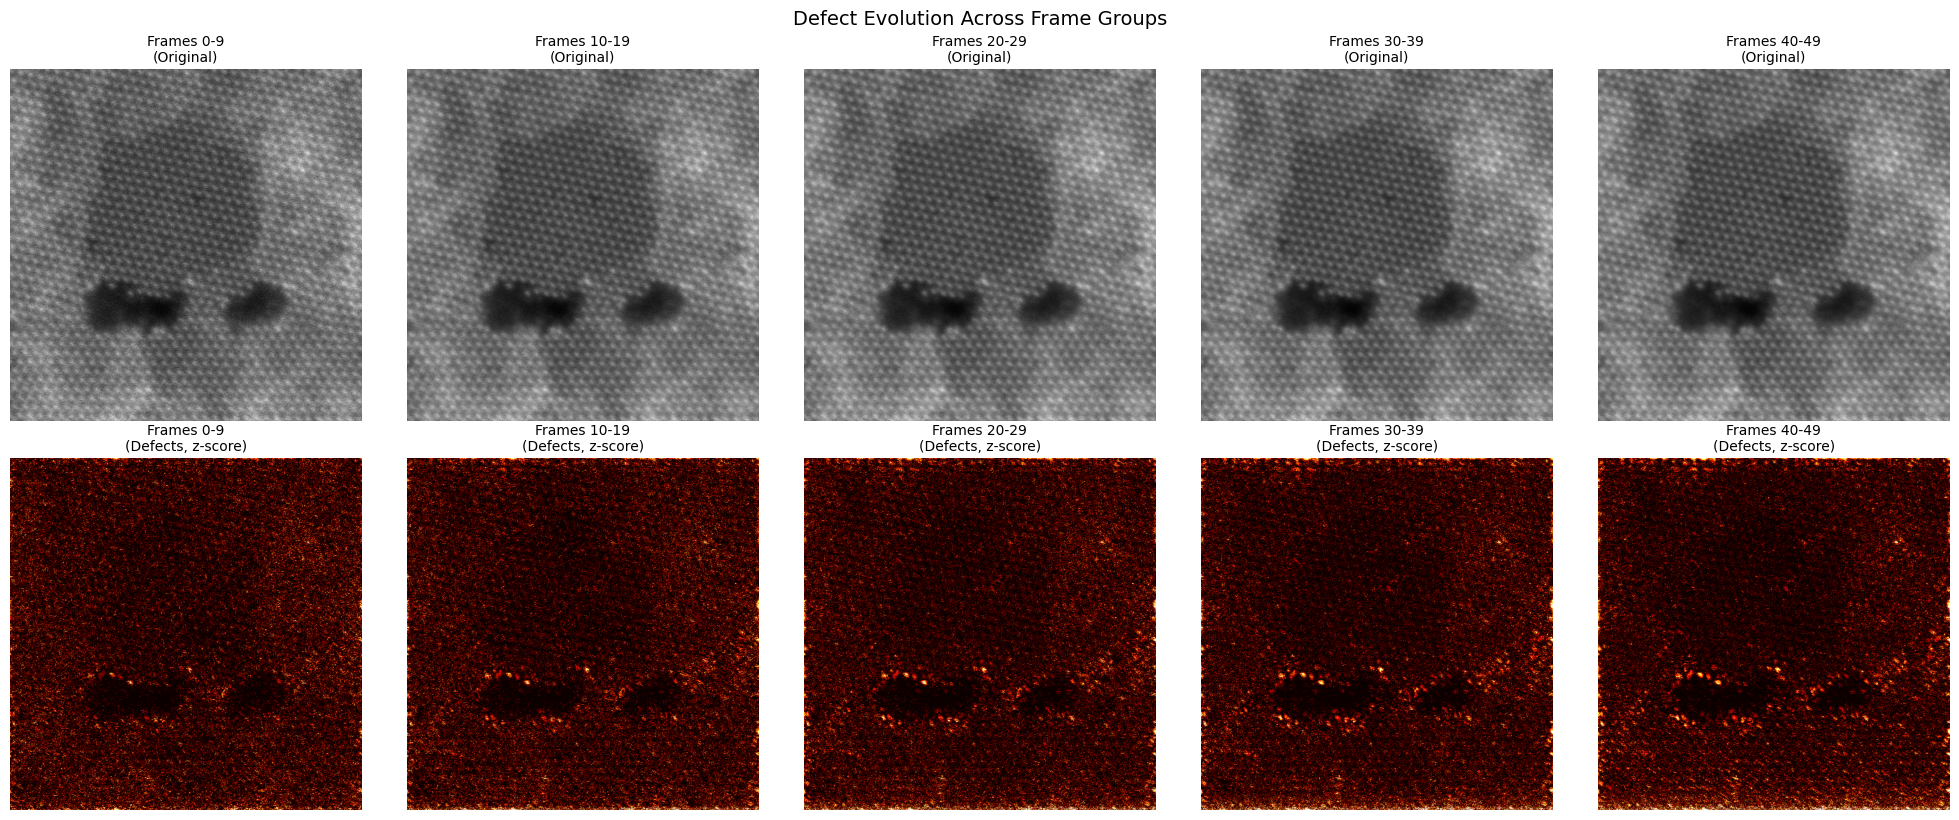

In [7]:
# visualize defects for each group
fig, axes = plt.subplots(2, NUM_GROUPS, figsize=(20, 8))

for i, label in enumerate(group_labels):
    res = results[label]
    
    # original 
    axes[0, i].imshow(res['img_norm'], cmap='gray')
    axes[0, i].set_title(f'{label}\n(Original)', fontsize=10)
    axes[0, i].axis('off')
    
    # enhanced defects (z-scored)
    im = axes[1, i].imshow(res['defects_enhanced'], cmap='hot', vmin=0, vmax=5)
    axes[1, i].set_title(f'{label}\n(Defects, z-score)', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.suptitle('Defect Evolution Across Frame Groups', y=1.02, fontsize=14)
plt.show()

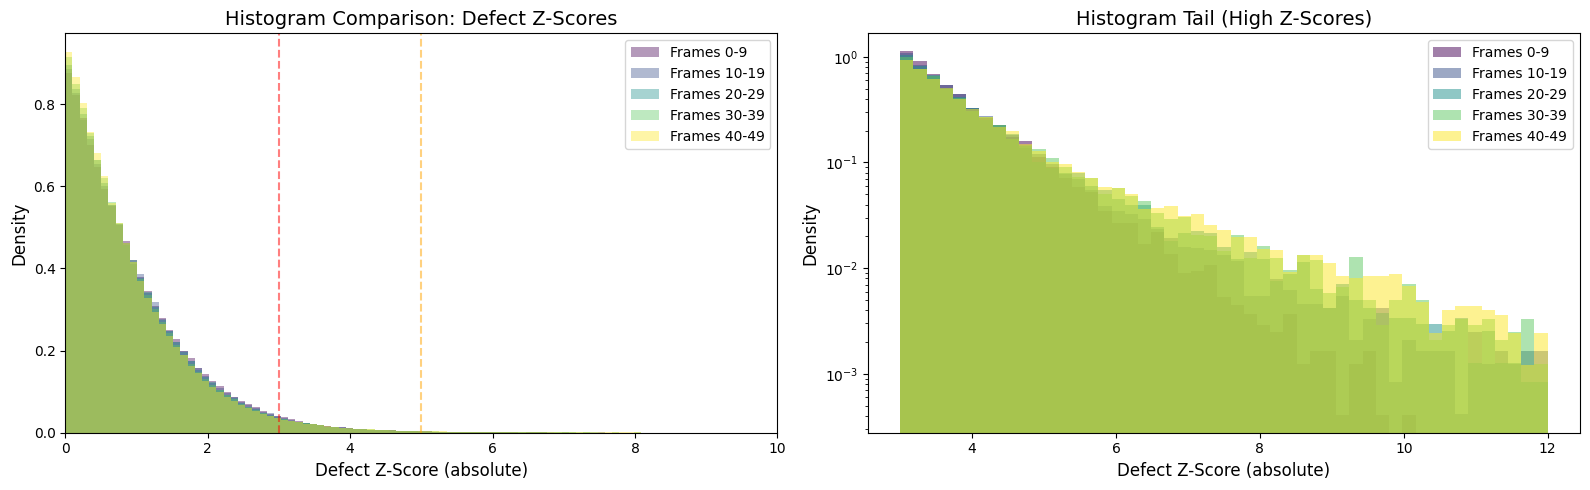

In [8]:
# hist comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.viridis(np.linspace(0, 1, NUM_GROUPS))

# left - overlapping hist
bins = np.linspace(0, 10, 100)
for i, label in enumerate(group_labels):
    defects = results[label]['defects_enhanced'].flatten()
    axes[0].hist(defects, bins=bins, alpha=0.4, color=colors[i], 
                 label=label, density=True)

axes[0].set_xlabel('Defect Z-Score (absolute)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Histogram Comparison: Defect Z-Scores', fontsize=14)
axes[0].legend()
axes[0].set_xlim(0, 10)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='z=3')
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='z=5')

# right - zoomed in on the tail (high z-scores)
bins_tail = np.linspace(3, 12, 50)
for i, label in enumerate(group_labels):
    defects = results[label]['defects_enhanced'].flatten()
    axes[1].hist(defects, bins=bins_tail, alpha=0.5, color=colors[i], 
                 label=label, density=True)

axes[1].set_xlabel('Defect Z-Score (absolute)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Histogram Tail (High Z-Scores)', fontsize=14)
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

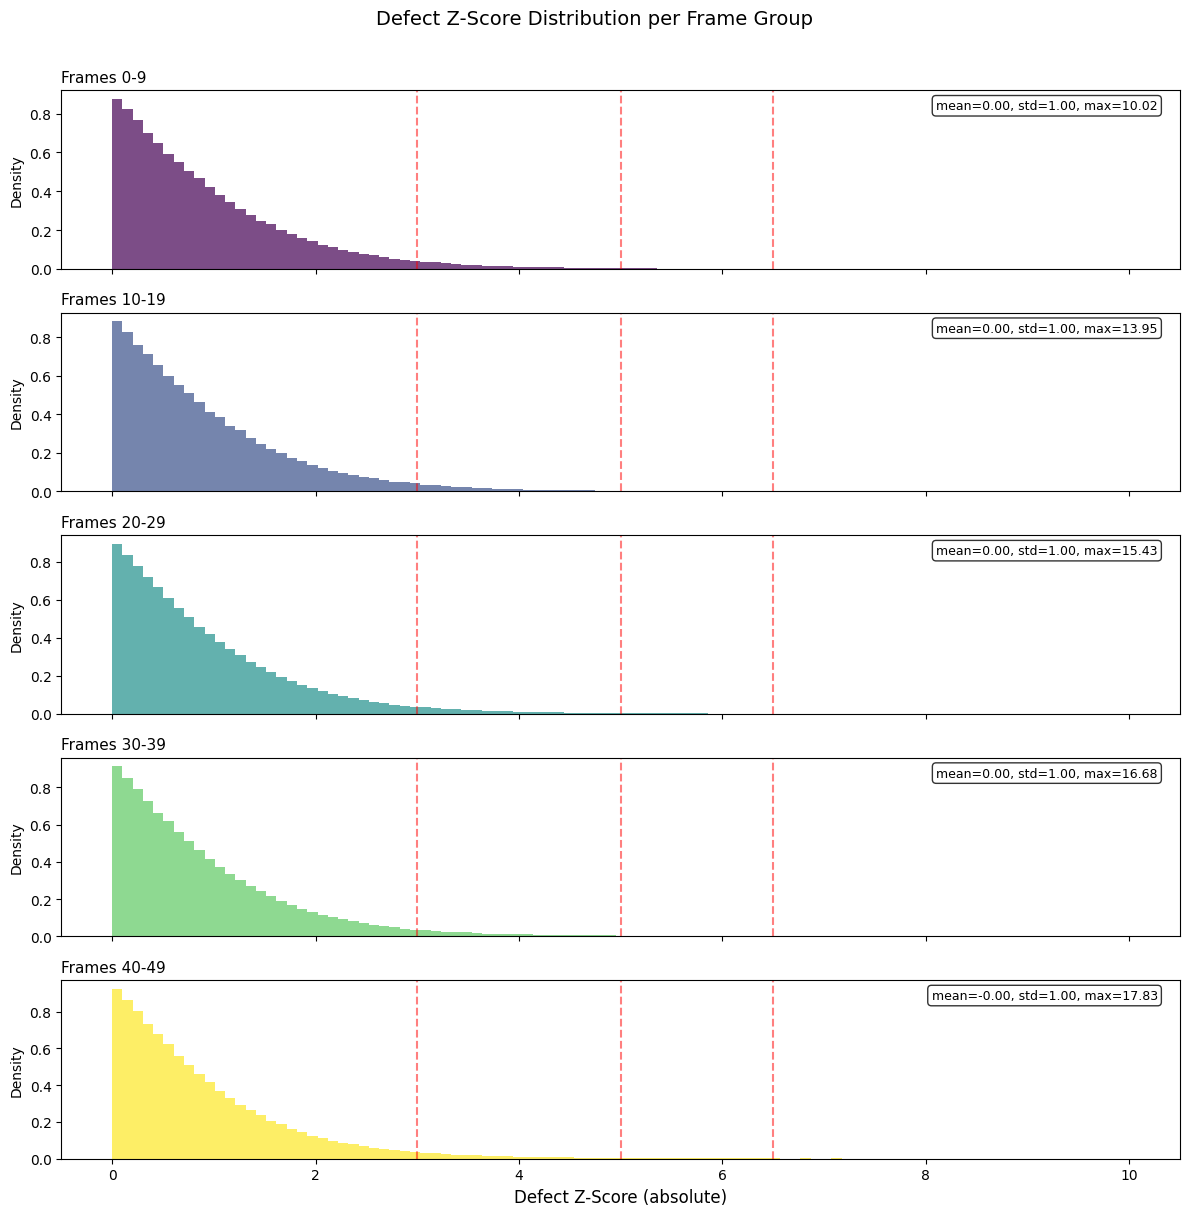

In [9]:
# individual hist
fig, axes = plt.subplots(NUM_GROUPS, 1, figsize=(12, 12), sharex=True)

bins = np.linspace(0, 10, 100)

for i, label in enumerate(group_labels):
    defects = results[label]['defects_enhanced'].flatten()
    
    axes[i].hist(defects, bins=bins, color=colors[i], alpha=0.7, density=True)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].set_title(label, fontsize=11, loc='left')
    
    for thresh in [3, 5, 6.5]:
        axes[i].axvline(x=thresh, color='red', linestyle='--', alpha=0.5)
    
    mean_val = defects.mean()
    std_val = defects.std()
    max_val = defects.max()
    axes[i].text(0.98, 0.95, f'mean={mean_val:.2f}, std={std_val:.2f}, max={max_val:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[-1].set_xlabel('Defect Z-Score (absolute)', fontsize=12)
plt.suptitle('Defect Z-Score Distribution per Frame Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# percentage of pixels above various thresholds
thresholds = [5, 6.5, 8]

print("=" * 80)
print("PERCENTAGE OF PIXELS ABOVE Z-SCORE THRESHOLDS")
print("=" * 80)

header = f"{'Group':<20}" + "".join([f"z>{t:<5}" for t in thresholds])
print(header)
print("-" * 80)

percentages = {}
for label in group_labels:
    defects = results[label]['defects_enhanced']
    total_pixels = defects.size
    
    pcts = []
    row = f"{label:<20}"
    for thresh in thresholds:
        pct = 100 * np.sum(defects > thresh) / total_pixels
        pcts.append(pct)
        row += f"{pct:>6.3f}%"
    print(row)
    percentages[label] = pcts

print("=" * 80)

PERCENTAGE OF PIXELS ABOVE Z-SCORE THRESHOLDS
Group               z>5    z>6.5  z>8    
--------------------------------------------------------------------------------
Frames 0-9           0.119% 0.023% 0.004%
Frames 10-19         0.153% 0.046% 0.017%
Frames 20-29         0.182% 0.063% 0.026%
Frames 30-39         0.217% 0.083% 0.038%
Frames 40-49         0.245% 0.104% 0.047%


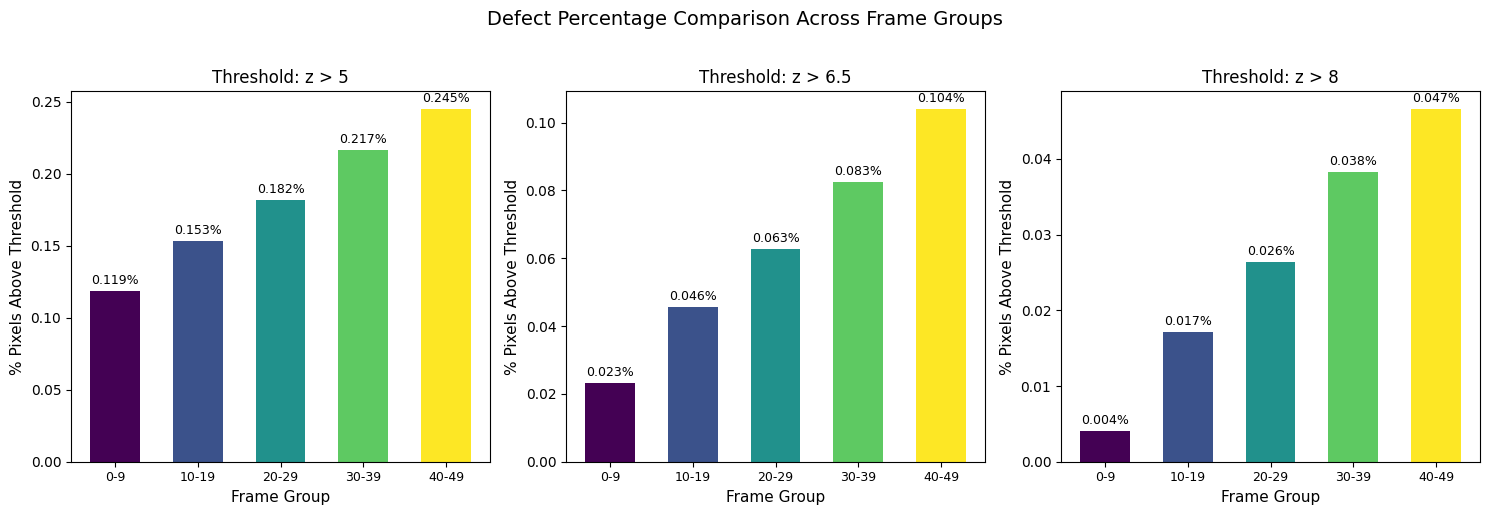

In [11]:
# bar chart comparison 
selected_thresholds = [5, 6.5, 8]

fig, axes = plt.subplots(1, len(selected_thresholds), figsize=(15, 5))

x = np.arange(NUM_GROUPS)
width = 0.6

for ax_idx, thresh in enumerate(selected_thresholds):
    thresh_idx = thresholds.index(thresh)
    pcts = [percentages[label][thresh_idx] for label in group_labels]
    
    bars = axes[ax_idx].bar(x, pcts, width, color=colors)
    axes[ax_idx].set_xlabel('Frame Group', fontsize=11)
    axes[ax_idx].set_ylabel('% Pixels Above Threshold', fontsize=11)
    axes[ax_idx].set_title(f'Threshold: z > {thresh}', fontsize=12)
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels([f'{i*10}-{i*10+9}' for i in range(NUM_GROUPS)], fontsize=9)
    
    for bar, pct in zip(bars, pcts):
        height = bar.get_height()
        axes[ax_idx].annotate(f'{pct:.3f}%',
                              xy=(bar.get_x() + bar.get_width()/2, height),
                              xytext=(0, 3), textcoords="offset points",
                              ha='center', va='bottom', fontsize=9)

plt.suptitle('Defect Percentage Comparison Across Frame Groups', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()